# Estimation of Obesity Levels Based On Eating Habits and Physical Condition

Dataset Source: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

**This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition.**

Contributer: Charchit (0xSquawk) | https://github.com/0xsquawk

Repository URL: https://github.com/0xsquawk/obesity_predictions

In [ ]:
# Initial setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
# Import the dataset
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544) 
  
# data (as pandas dataframes) 
X_raw = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features 
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets 
  
# metadata 
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.metadata) 
  
# variable information 
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables) 

{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

## 1. Exploratory Data Analysis

In [5]:
# Check all different target values
print(y.value_counts().reset_index())

            NObeyesdad  count
0       Obesity_Type_I    351
1     Obesity_Type_III    324
2      Obesity_Type_II    297
3   Overweight_Level_I    290
4  Overweight_Level_II    290
5        Normal_Weight    287
6  Insufficient_Weight    272


In [6]:
# Combining 'X' & 'y' dataframes for EDA
df = pd.concat([X_raw,y], axis=1)

# Check for null values and data types
print(df.info())

# Check numerical statistics 
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

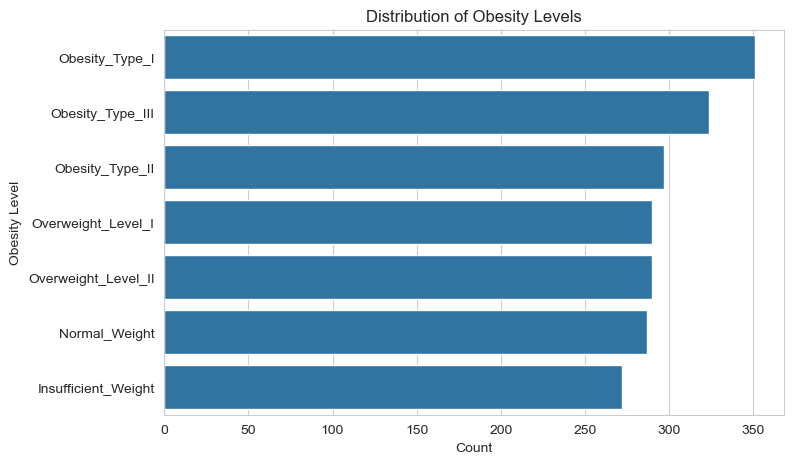

In [7]:
# Plot the distribution of obesity levels
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.title('Distribution of Obesity Levels')
plt.xlabel('Count')
plt.ylabel('Obesity Level')
plt.show()

**Observations**

- The dataset is well-balanced across all seven obesity categories, so no resampling technique is required.

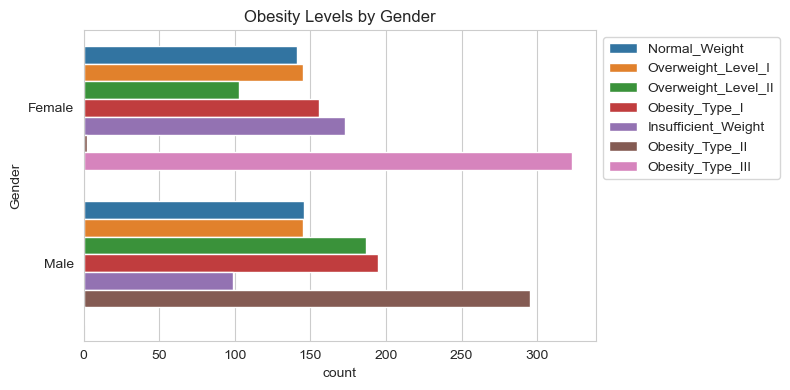

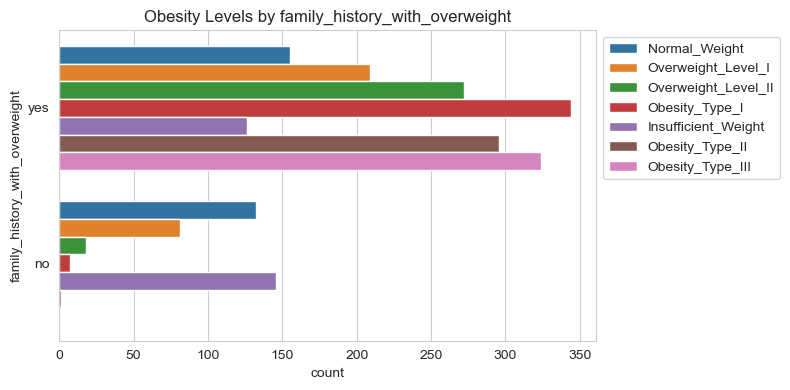

In [8]:
# List of categorical features
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

# Plot a few categorical features against the target
for col in ['Gender', 'family_history_with_overweight']:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, y=col, hue='NObeyesdad')
    plt.title(f'Obesity Levels by {col}')
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

**Observations**

- Individuals with a family history of being overweight skew heavily toward the higher obesity categories, indicating this is a strong predictor.

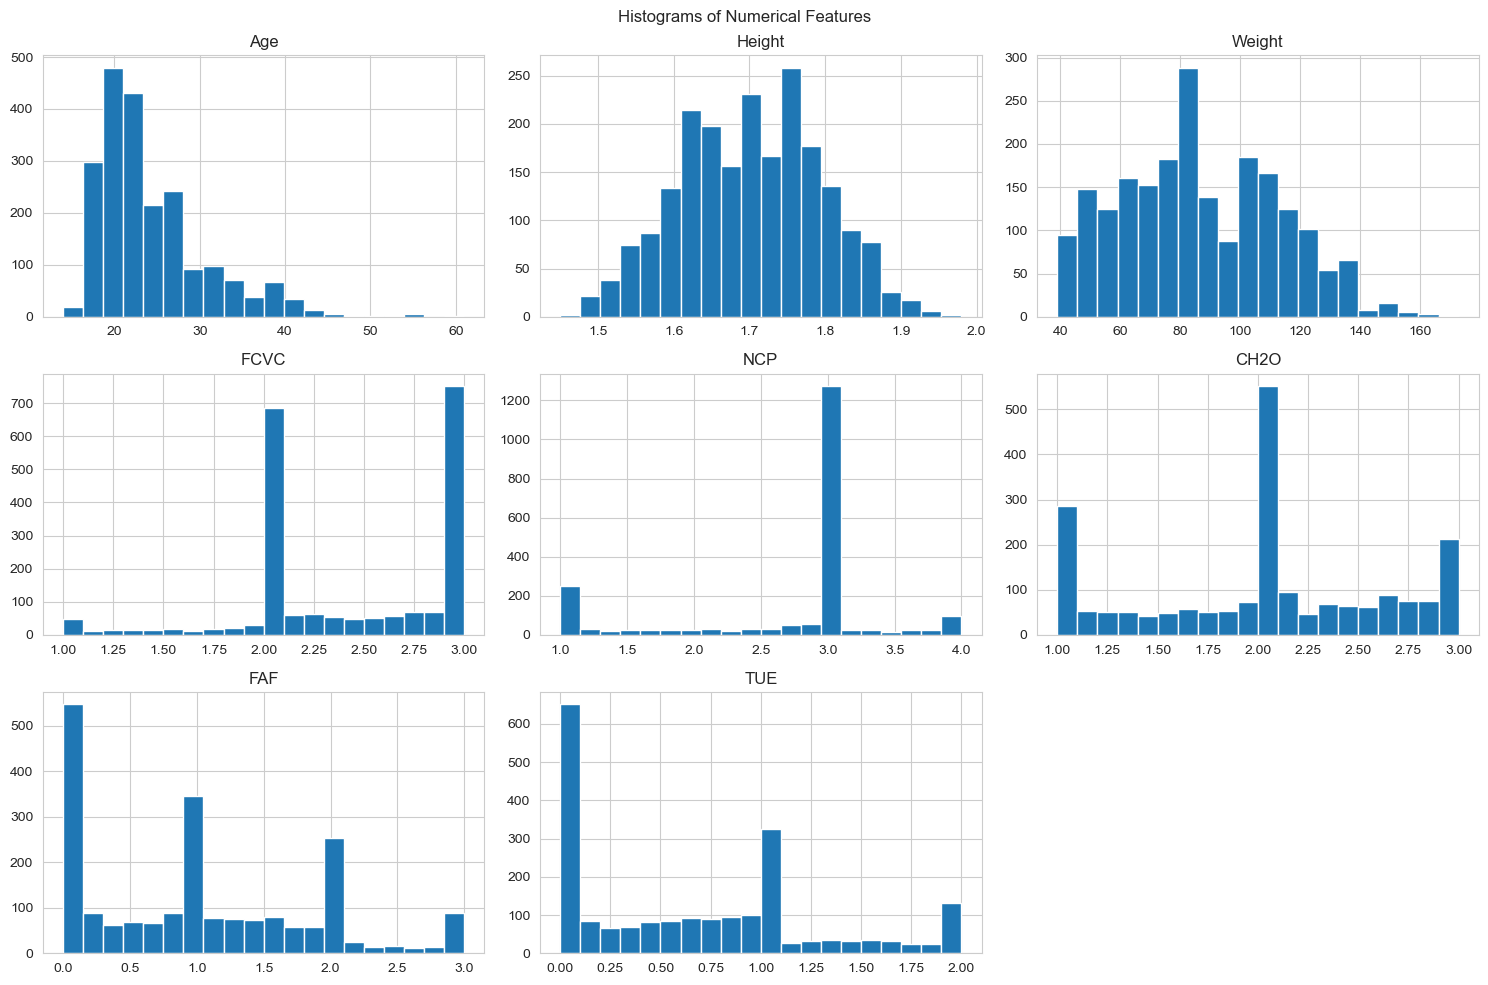

In [9]:
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Create histograms for numerical data
df[numerical_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

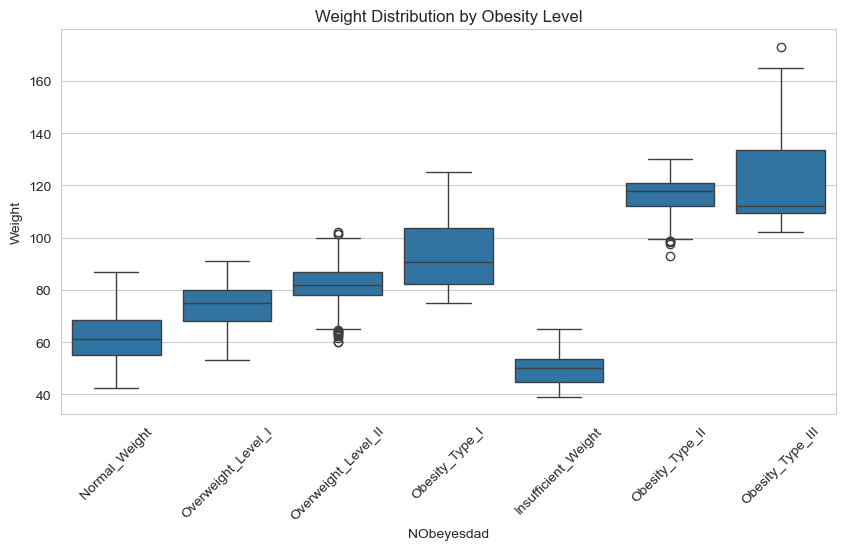

In [10]:
# Create a boxplot to see how Weight distributes across Obesity levels
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='NObeyesdad', y='Weight')
plt.xticks(rotation=45)
plt.title('Weight Distribution by Obesity Level')
plt.show()

**Observations**

- Weight increases in a clear, expected stair-step pattern across obesity levels. This makes sense since weight is directly tied to how obesity is calculated.

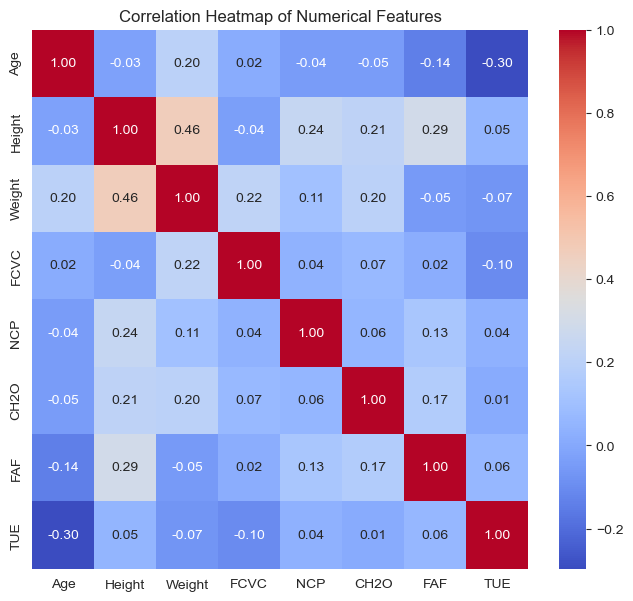

In [11]:
# Calculate correlation matrix for numerical features only
plt.figure(figsize=(8, 7))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Observations**

- No strong correlation was found between the numerical features, meaning each feature contributes unique information to the model.

## 2. Feature Engineering & Preprocessing

In [12]:
X = X_raw.copy()

In [13]:
# Calculate BMI and add it as a new feature
X['BMI'] = (X['Weight'] / (X['Height'] ** 2)).round(2)

# Dropping the 'Weight' & 'Height' features to avoid multicollinearity
X = X.drop(columns=['Weight', 'Height'])

In [14]:
# Convert target variable values into integers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_encoded = le.fit_transform(y.values.ravel())

In [15]:
from sklearn.model_selection import train_test_split
# Splitting the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=30)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Seperating columns based on data types
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
])

# Fit the engine on the training data ONLY, then transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the rules learned from the training data
X_test_processed = preprocessor.transform(X_test)

print(f"Original features: {X_train.shape[1]}")
print(f"Processed features: {X_train_processed.shape[1]}")

Original features: 15
Processed features: 30


## 3. Cross validation for model selection & Model Training

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

# Define a dictionary of models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=30),
    "Random Forest": RandomForestClassifier(random_state=30),
    "Support Vector Machine": SVC(random_state=30),
    "Gradient Boosting": GradientBoostingClassifier(random_state=30)
}

# Loop through each model and perform 5-fold cross-validation
print("Cross-Validation Results (Accuracy):\n" + "-"*35)

for name, model in models.items():
    # cv=5 means the data is split into 5 chunks (train on 4, test on 1, repeat 5 times)
    scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='accuracy')
    
    # Calculate the mean and standard deviation of the 5 scores
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    
    print(f"{name}:")
    print(f"  Mean Accuracy: {mean_score:.2f}% (+/- {std_score:.2f})\n")

Cross-Validation Results (Accuracy):
-----------------------------------
Logistic Regression:
  Mean Accuracy: 0.88% (+/- 0.02)

Random Forest:
  Mean Accuracy: 0.97% (+/- 0.01)

Support Vector Machine:
  Mean Accuracy: 0.91% (+/- 0.01)

Gradient Boosting:
  Mean Accuracy: 0.98% (+/- 0.01)



**Observations**

- Gradient Boosting is the best-performing model, with an accuracy of 0.98.
- Accuracy is a suitable metric here since the data was previously shown to be well-balanced.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# Grid of settings for Gradient Boosting
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5]
}

# Initialize the base model 
gb_base = GradientBoostingClassifier(random_state=30)

# Setup Grid Search Engine
grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 # Use all CPU cores
)

# Start the runing process
print("Searching for the best Gradient Boosting hyperparameters...")
grid_search.fit(X_train_processed, y_train)

# Output the winning config
print("\n--- Tuning Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Save the best model found
best_gb_model = grid_search.best_estimator_

Searching for the best Gradient Boosting hyperparameters...

--- Tuning Results ---
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.9763


In [19]:
# Make predictions on the completely unseen test data
test_predictions = best_gb_model.predict(X_test_processed)

# Print the detailed classification report
print("\n--- Final Test Set Performance ---")
print(classification_report(y_test, test_predictions, target_names=le.classes_))


--- Final Test Set Performance ---
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        51
      Normal_Weight       0.98      0.98      0.98        50
     Obesity_Type_I       0.98      0.98      0.98        83
    Obesity_Type_II       0.98      0.97      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        64
 Overweight_Level_I       0.94      1.00      0.97        58
Overweight_Level_II       0.98      0.95      0.97        59

           accuracy                           0.98       423
          macro avg       0.98      0.98      0.98       423
       weighted avg       0.98      0.98      0.98       423



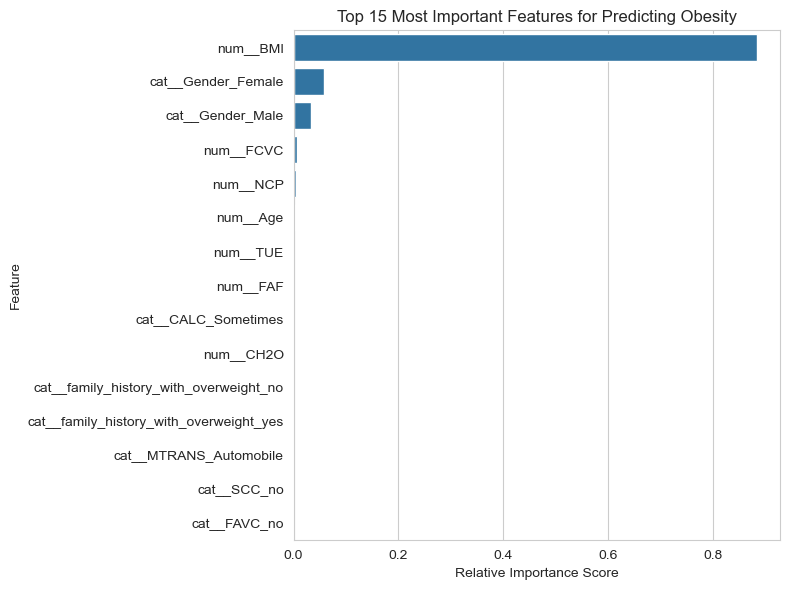

In [20]:
# 1. Get the updated feature names from your ColumnTransformer
# This ensures that one-hot encoded columns (like Gender_Male) are named correctly
feature_names = preprocessor.get_feature_names_out()

# 2. Extract the importance scores from your tuned model
# (If you used XGBoost, replace best_gb_model with your XGBoost model variable)
importances = best_gb_model.feature_importances_

# 3. Combine them into a pandas DataFrame for easy sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort the DataFrame from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 5. Plot the top 15 most important features
plt.figure(figsize=(8, 6))
sns.barplot(
    data=importance_df.head(15), 
    x='Importance', 
    y='Feature'
)
plt.title('Top 15 Most Important Features for Predicting Obesity')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Observations**

- Target leakage was identified: the model relies on the BMI feature for roughly 90% of its importance, effectively ignoring the other features. Since BMI is derived directly from weight and height, engineering this feature handed the algorithm the answer key.

The dataset is titled "Estimation of obesity levels based on eating habits and physical condition." At this point, the model is not predicting obesity from habits; it is simply classifying obesity based on BMI.

In [21]:
# Update the Features and Preprocessor
# Drop the 'BMI' feature
X_lifestyle = X.drop(columns=['BMI'])

# Re-split the data
X_train_life, X_test_life, y_train_life, y_test_life = train_test_split(X_lifestyle, y_encoded, test_size=0.2, random_state=30)

# Updated the columns list
numerical_cols_life = X_lifestyle.select_dtypes(include=['number']).columns.to_list()
categorical_cols_life = X_lifestyle.select_dtypes(exclude=['number']).columns.to_list()

# New preprocessor
preprocessor_life = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_life),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols_life)
    ])

# Fit & transform the new data
X_train_processed_life = preprocessor_life.fit_transform(X_train_life)
X_test_processed_life = preprocessor_life.transform(X_test_life)

### Cross validation on new data for model selection

In [22]:
# Define a dictionary of models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=30),
    "Random Forest": RandomForestClassifier(random_state=30),
    "Support Vector Machine": SVC(random_state=30),
    "Gradient Boosting": GradientBoostingClassifier(random_state=30)
}

# Loop through each model and perform 5-fold cross-validation
print("Cross-Validation Results (Accuracy):\n" + "-"*35)

for name, model in models.items():
    # cv=5 means the data is split into 5 chunks (train on 4, test on 1, repeat 5 times)
    scores = cross_val_score(model, X_train_processed_life, y_train_life, cv=5, scoring='accuracy')
    
    # Calculate the mean and standard deviation of the 5 scores
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    
    print(f"{name}:")
    print(f"  Mean Accuracy: {mean_score:.2f}% (+/- {std_score:.2f})\n")

Cross-Validation Results (Accuracy):
-----------------------------------
Logistic Regression:
  Mean Accuracy: 0.61% (+/- 0.03)

Random Forest:
  Mean Accuracy: 0.85% (+/- 0.02)

Support Vector Machine:
  Mean Accuracy: 0.77% (+/- 0.02)

Gradient Boosting:
  Mean Accuracy: 0.81% (+/- 0.03)



**Observations**

- After removing BMI, Random Forest is the top-performing model with an accuracy of 85%.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Grid settings for RandomForest
param_grid_rf = {
    'n_estimators':[100, 200, 300],
    'max_depth':[None, 15, 25],
    'min_samples_split': [2, 5]
}

# Initialize the base model
rf = RandomForestClassifier(random_state=30)

# Setup Grid Search Engine
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train and tune the model
print("Searching for the best Random Forest hyperparameters...")
grid_search_rf.fit(X_train_processed_life, y_train_life)

# Output the winning configuration
print("\n--- Tuning Results ---")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best CV Accuracy: {grid_search_rf.best_score_:.4f}")

# Save the best model
best_rf_model = grid_search_rf.best_estimator_

Searching for the best Random Forest hyperparameters...

--- Tuning Results ---
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy: 0.8625


In [24]:
# Make predictions on the unseen lifestyle test data
rf_predictions = best_rf_model.predict(X_test_processed_life)

# Print the detailed classification report
print("\n--- Random Forest Final Test Set Performance ---")
print(classification_report(y_test_life, rf_predictions, target_names=le.classes_))


--- Random Forest Final Test Set Performance ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.86      0.91        51
      Normal_Weight       0.56      0.80      0.66        50
     Obesity_Type_I       0.84      0.84      0.84        83
    Obesity_Type_II       0.88      0.91      0.90        58
   Obesity_Type_III       1.00      1.00      1.00        64
 Overweight_Level_I       0.80      0.71      0.75        58
Overweight_Level_II       0.83      0.66      0.74        59

           accuracy                           0.83       423
          macro avg       0.84      0.83      0.83       423
       weighted avg       0.84      0.83      0.83       423



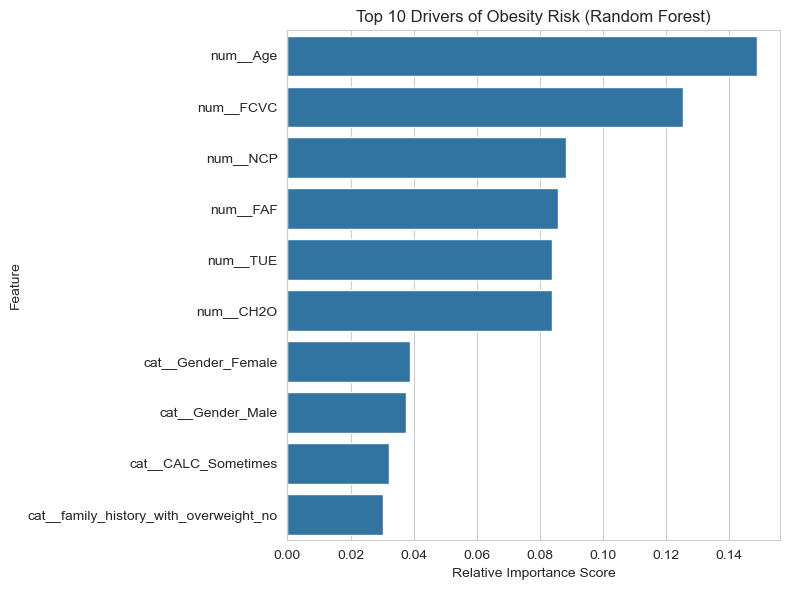

In [25]:
# Extract the feature names and importances from the tuned Random Forest
feature_names_rf = preprocessor_life.get_feature_names_out()
importances_rf = best_rf_model.feature_importances_

# Combine into a sorted DataFrame
importance_df_rf = pd.DataFrame({
    'Feature': feature_names_rf,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(8, 6))
sns.barplot(
    data=importance_df_rf.head(10), 
    x='Importance', 
    y='Feature'
)
plt.title('Top 10 Drivers of Obesity Risk (Random Forest)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Summary

- The obesity levels dataset is well-balanced across its seven classes, so accuracy is a reliable evaluation metric and no resampling was needed.
- Initial exploratory analysis showed that family history of overweight is a strong predictor, weight rises in a stair-step pattern with obesity level, and the numerical features are not strongly correlated with one another.
- A first modeling pass, which engineered a BMI feature, achieved 0.98 accuracy with Gradient Boosting, but feature importance revealed this was driven almost entirely by BMI itself, a case of target leakage since BMI is derived from weight and height.
- Removing BMI and Weight/Height and refitting on the remaining eating habit and lifestyle features gave a more honest evaluation: Random Forest was the best model, achieving 85% accuracy on unseen data.
- The final tuned Random Forest model relies on genuine lifestyle and demographic features rather than a derived proxy for the target, making it a more meaningful model of how eating habits and physical condition relate to obesity risk.